In [88]:
import pandas as pd
df = pd.read_csv("../data/raw/Energy_consumption.csv")
df.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


In [89]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   str    
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   str    
 6   LightingUsage      1000 non-null   str    
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   str    
 9   Holiday            1000 non-null   str    
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), str(5)
memory usage: 86.1 KB


,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.982026,45.395412,1500.052488,4.581000,15.132813,77.055873
std,2.836850,8.518905,288.418873,2.865598,8.745917,8.144112
min,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,22.645070,38.297722,1247.108548,2.000000,7.628385,71.544690
50%,24.751637,45.972116,1507.967426,5.000000,15.072296,76.943696
75%,27.418174,52.420066,1740.340165,7.000000,22.884064,82.921742
max,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120


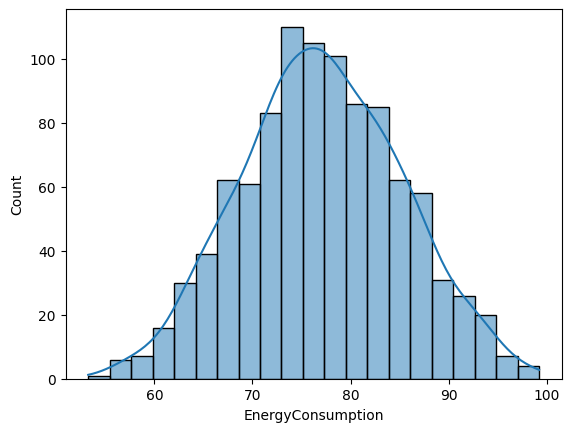

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["EnergyConsumption"], kde=True)
plt.show()

In [91]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["hour"] = df["Timestamp"].dt.hour
df["day"] = df["Timestamp"].dt.day
df["month"] = df["Timestamp"].dt.month
df["year"] = df["Timestamp"].dt.year
df = df.drop("Timestamp", axis=1)
df = pd.get_dummies(df, drop_first=True)
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Temperature          1000 non-null   float64
 1   Humidity             1000 non-null   float64
 2   SquareFootage        1000 non-null   float64
 3   Occupancy            1000 non-null   int64  
 4   RenewableEnergy      1000 non-null   float64
 5   EnergyConsumption    1000 non-null   float64
 6   hour                 1000 non-null   int32  
 7   day                  1000 non-null   int32  
 8   month                1000 non-null   int32  
 9   year                 1000 non-null   int32  
 10  HVACUsage_On         1000 non-null   bool   
 11  LightingUsage_On     1000 non-null   bool   
 12  DayOfWeek_Monday     1000 non-null   bool   
 13  DayOfWeek_Saturday   1000 non-null   bool   
 14  DayOfWeek_Sunday     1000 non-null   bool   
 15  DayOfWeek_Thursday   1000 non-null   bool   
 16  

,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption,hour,day,month,year,HVACUsage_On,LightingUsage_On,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,Holiday_Yes
0,25.139433,43.431581,1565.693999,5,2.774699,75.364373,0,1,1,2022,True,False,True,False,False,False,False,False,False
1,27.731651,54.225919,1411.064918,1,21.831384,83.401855,1,1,1,2022,True,True,False,True,False,False,False,False,False
2,28.704277,58.907658,1755.715009,2,6.764672,78.270888,2,1,1,2022,False,False,False,False,True,False,False,False,False
3,20.080469,50.371637,1452.316318,1,8.623447,56.519850,3,1,1,2022,False,True,False,False,False,False,False,True,False
4,23.097359,51.401421,1094.130359,9,3.071969,70.811732,4,1,1,2022,True,False,False,False,False,False,False,False,False


Split Data

In [92]:
from sklearn.model_selection import train_test_split
X = df.drop("EnergyConsumption", axis=1)
y = df["EnergyConsumption"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train Model

In [93]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
model.coef_
model.intercept_
print("model_coef:", model.coef_)
print("model_intercept:", model.intercept_)

model_coef: [ 1.99921824e+00 -3.53977291e-02 -4.44170424e-04  5.04822194e-01
  9.37809736e-02 -2.89720987e-02  1.58356310e-02  7.30490172e-01
  4.44089210e-16  4.49676359e+00  1.64324899e+00  1.41038455e-01
  4.27407371e-01 -4.87251973e-02  3.93199566e-01  1.34358913e-02
 -1.39563564e-01  5.09224762e-01]
model_intercept: 21.46776538294708


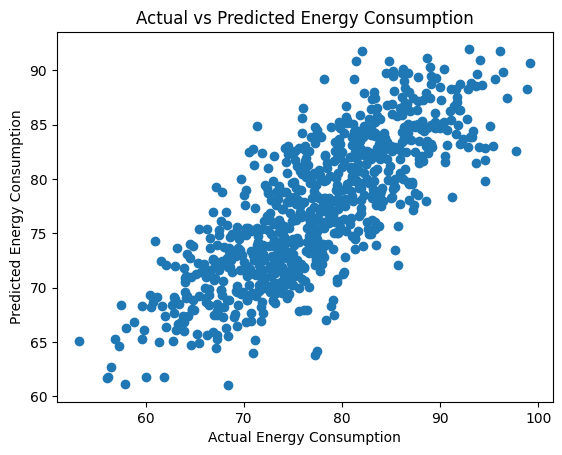

In [94]:
# Make predictions
y_pred = model.predict(X_train)
# Plot the graph - predicted vs actual values
plt.scatter(y_train, y_pred)
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.show()